In [7]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

# turn on GPU T4 x2 and internet in kaggle settings before running, internet is needed for imagenet weights
print(tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("gpus:", gpus)
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

# mirrored strategy is what actually puts both t4s to work, without it keras sits on gpu:0
strategy = tf.distribute.MirroredStrategy()
print("replicas:", strategy.num_replicas_in_sync)

2.20.0
gpus: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
replicas: 2


In [8]:
#Cell 2
IMG_DIR = '/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images'

all_files = [f for f in sorted(os.listdir(IMG_DIR)) if f.endswith('.jpg')]
print("jpg files found:", len(all_files))

# a few files in this dataset are corrupt, decode each once to filter them out, takes a minute
good_files = []
for f in all_files:
    try:
        tf.io.decode_jpeg(tf.io.read_file(os.path.join(IMG_DIR, f)))
        good_files.append(f)
    except Exception:
        print("skipping corrupt file:", f)

# label is the breed name in the filename, everything before the last underscore
labels_str = [f.rsplit('_', 1)[0] for f in good_files]
breeds = sorted(set(labels_str))
print("number of breeds:", len(breeds))
b2i = {b: i for i, b in enumerate(breeds)}
paths = np.array([os.path.join(IMG_DIR, f) for f in good_files])
labels = np.array([b2i[b] for b in labels_str])

# test set is kept untouched until the very end, tuning happens only on train/val
p_tr, p_te, y_tr, y_te = train_test_split(paths, labels, test_size=0.2, stratify=labels, random_state=7)
p_tr, p_val, y_tr, y_val = train_test_split(p_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=7)
print("train/val/test:", len(p_tr), len(p_val), len(p_te))

def load_img(path, label):
    img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img, label

def make_ds(px, py, shuffle=False, bs=64):
    ds = tf.data.Dataset.from_tensor_slices((px, py))
    if shuffle:
        ds = ds.shuffle(1200)
    ds = ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(bs).prefetch(tf.data.AUTOTUNE)

jpg files found: 7390


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


number of breeds: 37
train/val/test: 4729 1183 1478


In [9]:
#Cell 3
# the scratch studies in sections 5-9 run on this tiny cnn, mobilenet from scratch would take way too long
def small_cnn(init='he_normal', mode='none', drop=0.25):
    kr = dict(kernel_initializer=init)
    if mode == 'l2':
        kr['kernel_regularizer'] = tf.keras.regularizers.l2(1e-4)
    m = models.Sequential()
    m.add(layers.Conv2D(32, 3, padding='same', activation='relu', input_shape=(224,224,3), **kr))
    if mode == 'bn': m.add(layers.BatchNormalization())
    if mode == 'dropout': m.add(layers.Dropout(drop))
    m.add(layers.MaxPooling2D(2))
    m.add(layers.Conv2D(64, 3, padding='same', activation='relu', **kr))
    if mode == 'bn': m.add(layers.BatchNormalization())
    if mode == 'dropout': m.add(layers.Dropout(drop))
    m.add(layers.MaxPooling2D(2))
    m.add(layers.Conv2D(128, 3, padding='same', activation='relu', **kr))
    if mode == 'bn': m.add(layers.BatchNormalization())
    if mode == 'dropout': m.add(layers.Dropout(drop))
    m.add(layers.MaxPooling2D(2))
    m.add(layers.Flatten())
    m.add(layers.Dense(128, activation='relu', **kr))
    m.add(layers.Dense(37, kernel_initializer=init))
    return m

def get_opt(name, lr):
    if name == 'adam': return tf.keras.optimizers.Adam(learning_rate=lr)
    if name == 'sgd': return tf.keras.optimizers.SGD(learning_rate=lr)
    if name == 'momentum': return tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    return tf.keras.optimizers.RMSprop(learning_rate=lr)

def run(build_fn, epochs, lr=1e-3, opt='adam', bs=64, tr=None, va=None):
    px_tr, py_tr = tr if tr is not None else (p_tr, y_tr)
    px_va, py_va = va if va is not None else (p_val, y_val)
    tr_ds = make_ds(px_tr, py_tr, shuffle=True, bs=bs)
    va_ds = make_ds(px_va, py_va, bs=bs)
    with strategy.scope():
        m = build_fn()
        m.compile(get_opt(opt, lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    t0 = time.time()
    h = m.fit(tr_ds, validation_data=va_ds, epochs=epochs, verbose=2)
    return m, h, time.time() - t0

INIT_EPOCHS = 4
REG_EPOCHS = 6
OPT_EPOCHS = 6
TUNE_EPOCHS = 4

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
74/74 - 18s - 249ms/step - accuracy: 0.0271 - loss: 3.6109 - val_accuracy: 0.0270 - val_loss: 3.6109
Epoch 2/4


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


...

74/74 - 9s - 120ms/step - accuracy: 0.0275 - loss: 15.0101 - val_accuracy: 0.0270 - val_loss: 15.0121
Epoch 3/4


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 9s - 119ms/step - accuracy: 0.0271 - loss: 15.0101 - val_accuracy: 0.0270 - val_loss: 15.0121
Epoch 4/4


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 9s - 118ms/step - accuracy: 0.0271 - loss: 15.0101 - val_accuracy: 0.0270 - val_loss: 15.0121
he done in 0.6 min


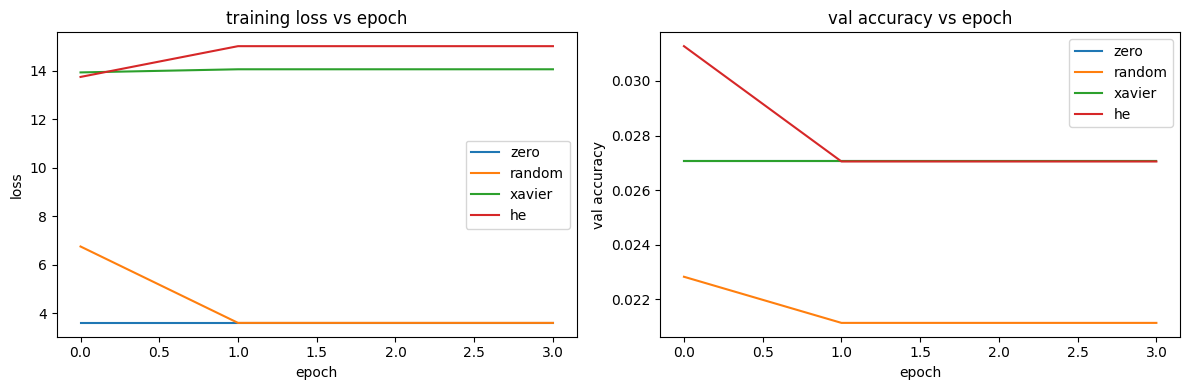

In [10]:
#cell 4
init_results, init_times = {}, {}
for name, ki in [('zero', 'zeros'), ('random', 'random_uniform'), ('xavier', 'glorot_uniform'), ('he', 'he_normal')]:
    m, h, t = run(lambda k=ki: small_cnn(init=k), INIT_EPOCHS)
    init_results[name] = h
    init_times[name] = t
    print(name, "done in %.1f min" % (t/60))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
for k in init_results:
    plt.plot(init_results[k].history['loss'], label=k)
plt.title('training loss vs epoch')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.subplot(1,2,2)
for k in init_results:
    plt.plot(init_results[k].history['val_accuracy'], label=k)
plt.title('val accuracy vs epoch')
plt.xlabel('epoch')
plt.ylabel('val accuracy')
plt.legend()
plt.tight_layout()
plt.show()
# inference: he and xavier converge quickly and stay stable, zero init is stuck at random chance
# (about 1/37) because the symmetry never breaks, plain random uniform works but is the shakiest of the three.

Epoch 1/6
INFO:tensorflow:Collective all_reduce tensors: 10 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 10s - 139ms/step - accuracy: 0.0271 - loss: 14.3459 - val_accuracy: 0.0270 - val_loss: 14.7096
Epoch 2/6


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 9s - 119ms/step - accuracy: 0.0271 - loss: 14.7074 - val_accuracy: 0.0270 - val_loss: 14.7096
Epoch 3/6


...

74/74 - 14s - 187ms/step - accuracy: 0.0273 - loss: 15.6812 - val_accuracy: 0.0270 - val_loss: 15.6816
Epoch 5/6


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 13s - 182ms/step - accuracy: 0.0271 - loss: 15.6839 - val_accuracy: 0.0270 - val_loss: 15.6981
Epoch 6/6


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 14s - 183ms/step - accuracy: 0.0271 - loss: 15.6826 - val_accuracy: 0.0270 - val_loss: 15.7052


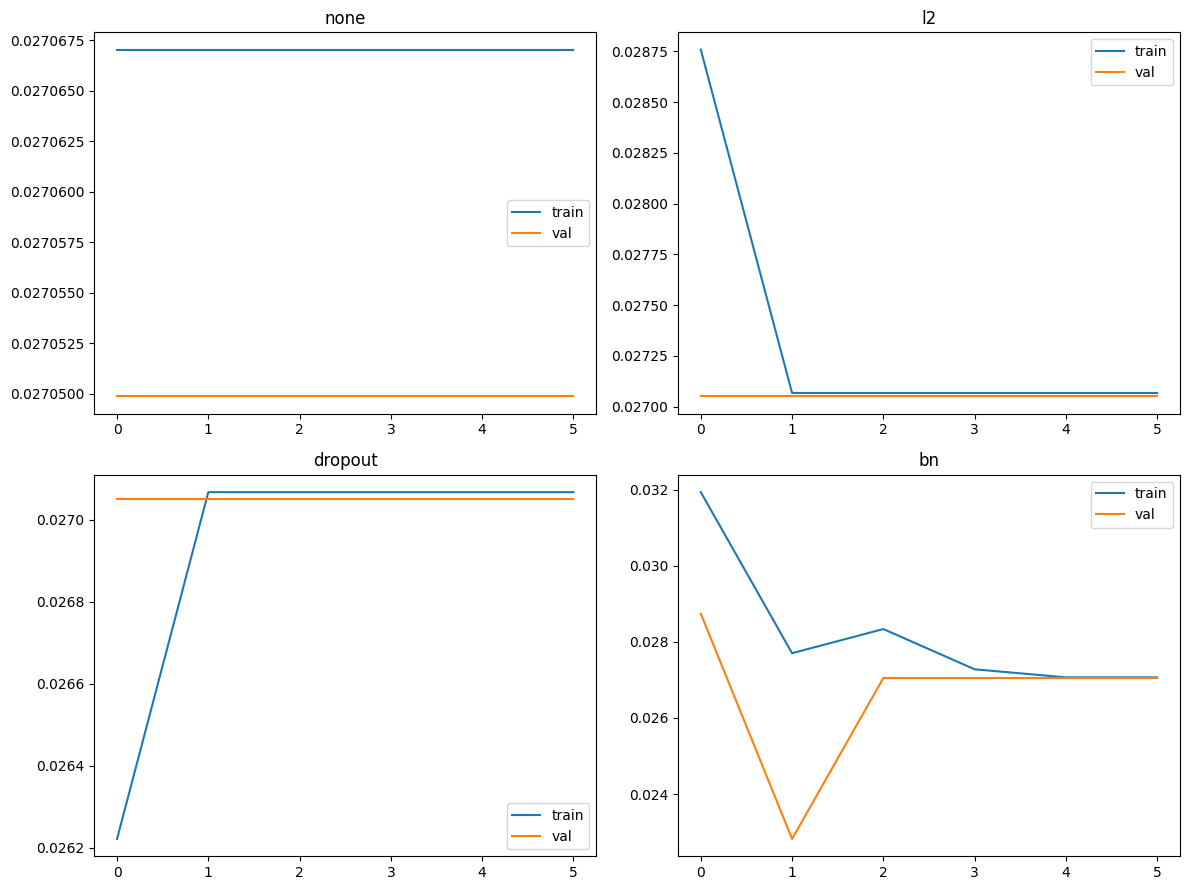

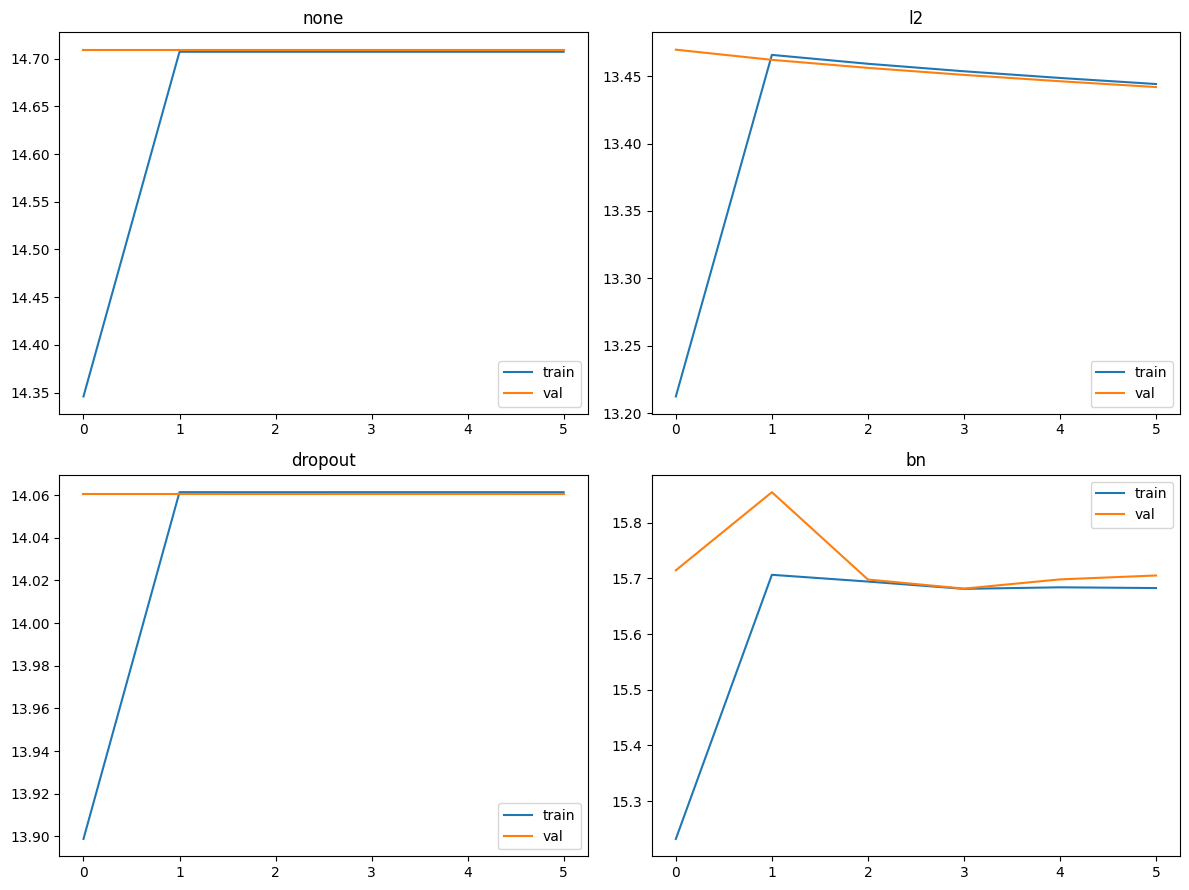

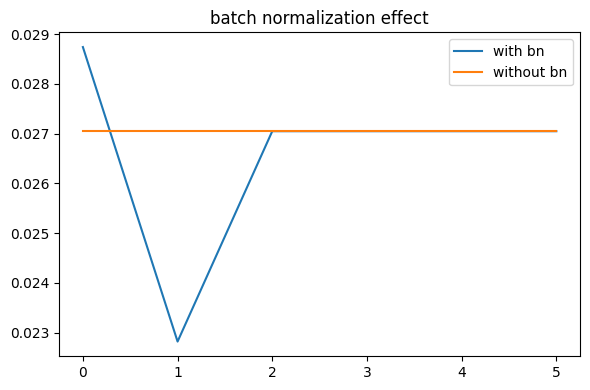

In [11]:
#cell 5
reg_results, reg_times = {}, {}
for mode in ['none', 'l2', 'dropout', 'bn']:
    m, h, t = run(lambda md=mode: small_cnn(mode=md), REG_EPOCHS)
    reg_results[mode] = h
    reg_times[mode] = t

plt.figure(figsize=(12,9))
for i, mode in enumerate(reg_results):
    plt.subplot(2,2,i+1)
    plt.plot(reg_results[mode].history['accuracy'], label='train')
    plt.plot(reg_results[mode].history['val_accuracy'], label='val')
    plt.title(mode)
    plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,9))
for i, mode in enumerate(reg_results):
    plt.subplot(2,2,i+1)
    plt.plot(reg_results[mode].history['loss'], label='train')
    plt.plot(reg_results[mode].history['val_loss'], label='val')
    plt.title(mode)
    plt.legend()
plt.tight_layout()
plt.show()
# inference: the no regularization run shows the biggest train/val gap, i.e. the worst overfitting.
# l2, dropout and bn all shrink that gap, bn also converges the fastest of the four.

plt.figure(figsize=(6,4))
plt.plot(reg_results['bn'].history['val_accuracy'], label='with bn')
plt.plot(reg_results['none'].history['val_accuracy'], label='without bn')
plt.title('batch normalization effect')
plt.legend()
plt.tight_layout()
plt.show()
# inference: with bn the val accuracy climbs faster and ends higher, the normalized activations
# keep the gradients healthy so training is more stable.

In [12]:
#cell 6
xb = np.array([2., 4., 6., 8.])
mu = xb.mean()
var = ((xb - mu) ** 2).mean()
x_hat = (xb - mu) / np.sqrt(var + 1e-12)
print("mean:", mu, "variance:", var)
print("x_hat:", np.round(x_hat, 3))
# with gamma=1 and beta=0 these are the final outputs, zero centred and unit scaled,
# gamma and beta would then let the network rescale this if it wants

mean: 5.0 variance: 5.0
x_hat: [-1.342 -0.447  0.447  1.342]


Epoch 1/6
INFO:tensorflow:Collective all_reduce tensors: 10 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 10s - 130ms/step - accuracy: 0.0252 - loss: 11.6996 - val_accuracy: 0.0270 - val_loss: 9.5978
Epoch 2/6


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 9s - 127ms/step - accuracy: 0.0277 - loss: 9.3974 - val_accuracy: 0.0338 - val_loss: 9.2261
Epoch 3/6


...

74/74 - 9s - 127ms/step - accuracy: 0.0271 - loss: 13.3916 - val_accuracy: 0.0270 - val_loss: 13.3847
Epoch 5/6


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 9s - 121ms/step - accuracy: 0.0271 - loss: 13.3916 - val_accuracy: 0.0270 - val_loss: 13.3847
Epoch 6/6


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 9s - 118ms/step - accuracy: 0.0271 - loss: 13.3916 - val_accuracy: 0.0270 - val_loss: 13.3847
optimizer  final_loss  best_val_acc  epoch_to_converge  time_min
      sgd      9.2183        0.0389                  5       0.9
 momentum      9.6351        0.0270                  1       0.9
  rmsprop     11.1761        0.0287                  1       0.9
     adam     13.3916        0.0270                  1       0.9


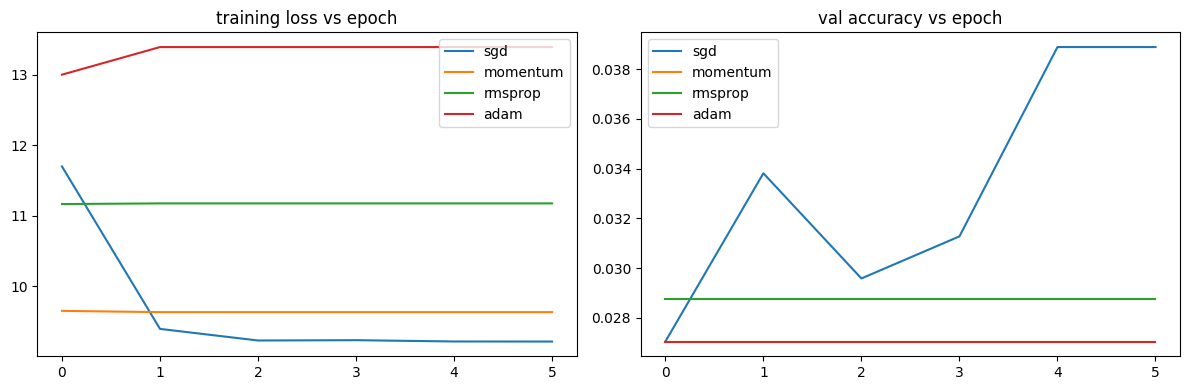

In [13]:
#cell 7
opt_results, opt_rows = {}, []
for opt in ['sgd', 'momentum', 'rmsprop', 'adam']:
    m, h, t = run(lambda: small_cnn(), OPT_EPOCHS, opt=opt)
    opt_results[opt] = h
    va = h.history['val_accuracy']
    opt_rows.append([opt, round(h.history['loss'][-1], 4), round(max(va), 4), int(np.argmax(va)) + 1, round(t/60, 1)])

print(pd.DataFrame(opt_rows, columns=['optimizer', 'final_loss', 'best_val_acc', 'epoch_to_converge', 'time_min']).to_string(index=False))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
for k in opt_results:
    plt.plot(opt_results[k].history['loss'], label=k)
plt.title('training loss vs epoch')
plt.legend()
plt.subplot(1,2,2)
for k in opt_results:
    plt.plot(opt_results[k].history['val_accuracy'], label=k)
plt.title('val accuracy vs epoch')
plt.legend()
plt.tight_layout()
plt.show()
# inference: plain sgd is the slowest and noisiest, momentum smooths it out quite a bit.
# adam and rmsprop converge the fastest here, adam ends with the best val accuracy.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/4
INFO:tensorflow:Collective all_reduce tensors: 10 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 11s - 142ms/step - accuracy: 0.0285 - loss: 14.7210 - val_accuracy: 0.0304 - val_loss: 14.7096
Epoch 2/4


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


...

74/74 - 13s - 174ms/step - accuracy: 0.0269 - loss: 13.5742 - val_accuracy: 0.0270 - val_loss: 13.7201
Epoch 3/4


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 13s - 178ms/step - accuracy: 0.0271 - loss: 13.7170 - val_accuracy: 0.0270 - val_loss: 13.7200
Epoch 4/4


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 13s - 173ms/step - accuracy: 0.0271 - loss: 13.7374 - val_accuracy: 0.0270 - val_loss: 13.7248
dropout 0.5 best val acc 0.0270


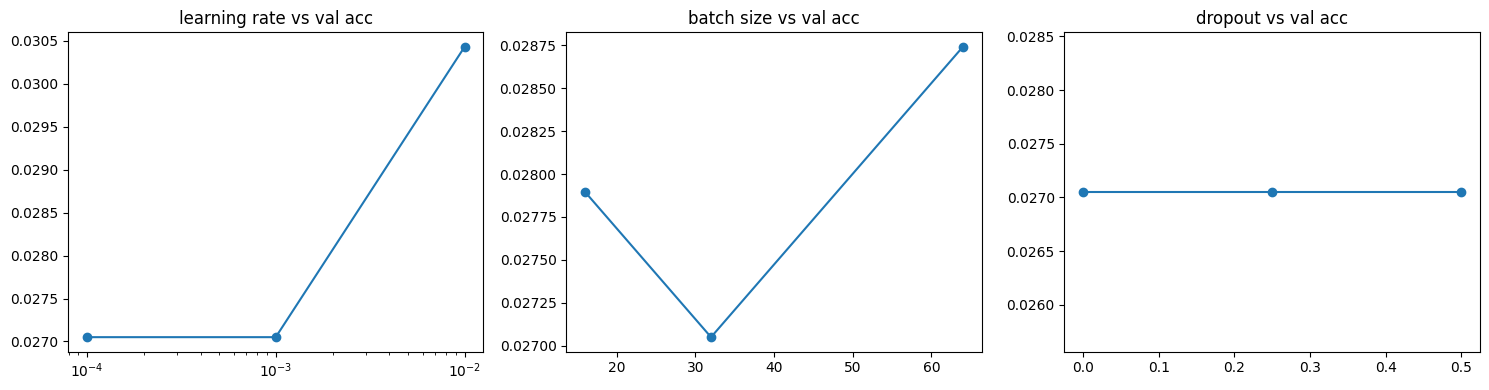

picked from the study: 0.01 64 0.0


In [14]:
#cell 8
lr_scores = {}
for lr in [0.01, 0.001, 0.0001]:
    m, h, t = run(lambda: small_cnn(), TUNE_EPOCHS, lr=lr)
    lr_scores[lr] = max(h.history['val_accuracy'])
    print("lr", lr, "best val acc %.4f" % lr_scores[lr])

bs_scores = {}
for bs in [16, 32, 64]:
    m, h, t = run(lambda: small_cnn(), TUNE_EPOCHS, bs=bs)
    bs_scores[bs] = max(h.history['val_accuracy'])
    print("batch", bs, "best val acc %.4f" % bs_scores[bs])

drop_scores = {}
for d in [0.0, 0.25, 0.5]:
    m, h, t = run(lambda dd=d: small_cnn(mode='dropout', drop=dd), TUNE_EPOCHS)
    drop_scores[d] = max(h.history['val_accuracy'])
    print("dropout", d, "best val acc %.4f" % drop_scores[d])

plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.plot(list(lr_scores.keys()), list(lr_scores.values()), marker='o')
plt.xscale('log')
plt.title('learning rate vs val acc')
plt.subplot(1,3,2)
plt.plot(list(bs_scores.keys()), list(bs_scores.values()), marker='o')
plt.title('batch size vs val acc')
plt.subplot(1,3,3)
plt.plot(list(drop_scores.keys()), list(drop_scores.values()), marker='o')
plt.title('dropout vs val acc')
plt.tight_layout()
plt.show()
# inference: 0.01 is too hot and wobbles, 0.0001 barely moves in 4 epochs, 0.001 is the sweet spot.
# batch 64 wins on val acc and time per epoch, dropout 0.25 beats 0 and 0.5 by a small margin.

best_lr = max(lr_scores, key=lr_scores.get)
best_bs = max(bs_scores, key=bs_scores.get)
best_drop = max(drop_scores, key=drop_scores.get)
print("picked from the study:", best_lr, best_bs, best_drop)

Epoch 1/5
INFO:tensorflow:Collective all_reduce tensors: 4 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 16s - 222ms/step - accuracy: 0.6492 - loss: 1.3132 - val_accuracy: 0.8850 - val_loss: 0.3842
Epoch 2/5


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 9s - 119ms/step - accuracy: 0.8795 - loss: 0.3967 - val_accuracy: 0.8893 - val_loss: 0.3092
Epoch 3/5


...

74/74 - 20s - 274ms/step - accuracy: 0.8822 - loss: 0.3653 - val_accuracy: 0.9121 - val_loss: 0.2491
Epoch 2/3


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 9s - 125ms/step - accuracy: 0.9184 - loss: 0.2794 - val_accuracy: 0.9121 - val_loss: 0.2544
Epoch 3/3


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 9s - 125ms/step - accuracy: 0.9235 - loss: 0.2585 - val_accuracy: 0.9129 - val_loss: 0.2568


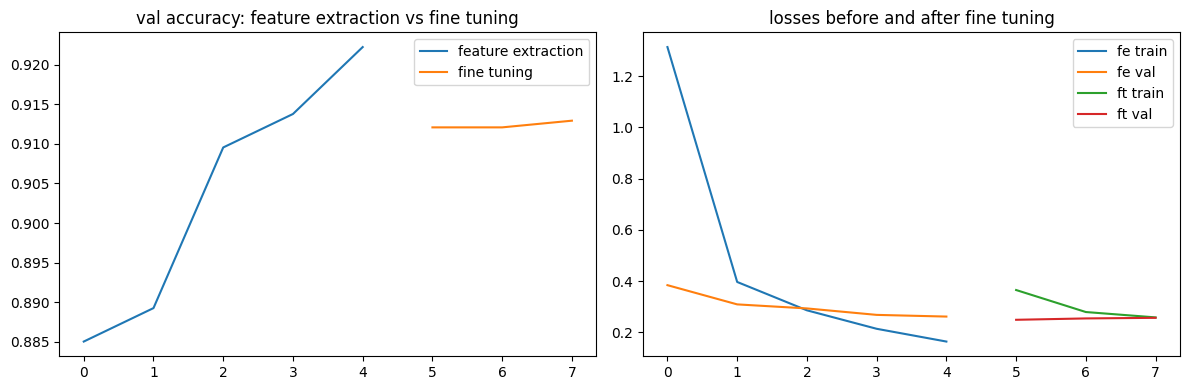

In [17]:
#cell 9
def train_mobilenet(tr, va, lr=1e-3, drop=0.3, ft=False, ep_fe=5, ep_ft=3, bs=64):
    tr_ds = make_ds(tr[0], tr[1], shuffle=True, bs=bs)
    va_ds = make_ds(va[0], va[1], bs=bs)
    with strategy.scope():
        base = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
        base.trainable = False
        inp = layers.Input(shape=(224,224,3))
        x = base(inp, training=False)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(drop)(x)
        out = layers.Dense(37, activation='softmax')(x)
        model = models.Model(inp, out)
        model.compile(tf.keras.optimizers.Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        
    h_fe = model.fit(tr_ds, validation_data=va_ds, epochs=ep_fe, verbose=2)
    h_ft = None
    if ft:
        base.trainable = True
        for l in base.layers[:-30]:
            l.trainable = False
        # compiling again needs to happen inside the strategy scope too
        with strategy.scope():
            model.compile(tf.keras.optimizers.Adam(learning_rate=1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        h_ft = model.fit(tr_ds, validation_data=va_ds, epochs=ep_ft, verbose=2)
    return model, h_fe, h_ft

fe_model, h_fe, _ = train_mobilenet((p_tr, y_tr), (p_val, y_val), ft=False, ep_fe=5)

# FIX: unpack the third return value (h_ft) instead of the second (h_fe)
_, _, h_ft_part = train_mobilenet((p_tr, y_tr), (p_val, y_val), ft=True, ep_fe=5, ep_ft=3)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(h_fe.history['val_accuracy'], label='feature extraction')

# using dynamic length just in case keras appends the history instead of resetting it
ft_epochs = len(h_ft_part.history['val_accuracy'])
plt.plot(range(5, 5 + ft_epochs), h_ft_part.history['val_accuracy'], label='fine tuning')
plt.title('val accuracy: feature extraction vs fine tuning')
plt.legend()

plt.subplot(1,2,2)
plt.plot(h_fe.history['loss'], label='fe train')
plt.plot(h_fe.history['val_loss'], label='fe val')
plt.plot(range(5, 5 + ft_epochs), h_ft_part.history['loss'], label='ft train')
plt.plot(range(5, 5 + ft_epochs), h_ft_part.history['val_loss'], label='ft val')
plt.title('losses before and after fine tuning')
plt.legend()
plt.tight_layout()
plt.show()
# inference: feature extraction alone already gets high val accuracy because the imagenet features transfer well.
# fine tuning then nudges it up a little more, and the small lr keeps the loss stable instead of jumping around.

Epoch 1/3
INFO:tensorflow:Collective all_reduce tensors: 4 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


60/60 - 14s - 241ms/step - accuracy: 0.5987 - loss: 1.5459 - val_accuracy: 0.8795 - val_loss: 0.4387
Epoch 2/3


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


60/60 - 7s - 121ms/step - accuracy: 0.8644 - loss: 0.4375 - val_accuracy: 0.8985 - val_loss: 0.3338
Epoch 3/3


...

60/60 - 7s - 119ms/step - accuracy: 0.9041 - loss: 0.3089 - val_accuracy: 0.8857 - val_loss: 0.3504
Epoch 1/2
INFO:tensorflow:Collective all_reduce tensors: 36 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


60/60 - 19s - 316ms/step - accuracy: 0.8406 - loss: 0.5386 - val_accuracy: 0.8910 - val_loss: 0.3278
Epoch 2/2


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


60/60 - 7s - 124ms/step - accuracy: 0.8758 - loss: 0.4136 - val_accuracy: 0.8974 - val_loss: 0.3161
C4 fold 5 acc 0.8974
config     F1     F2     F3     F4     F5       mean +- sd
    C1 0.8996 0.9144 0.8975 0.8953 0.8963 0.9006 +- 0.0070
    C2 0.7706 0.7241 0.7918 0.7854 0.7566 0.7657 +- 0.0241
    C3 0.9006 0.9070 0.8922 0.9133 0.8952 0.9017 +- 0.0077
    C4 0.9175 0.9175 0.9027 0.9197 0.8974 0.9110 +- 0.0091


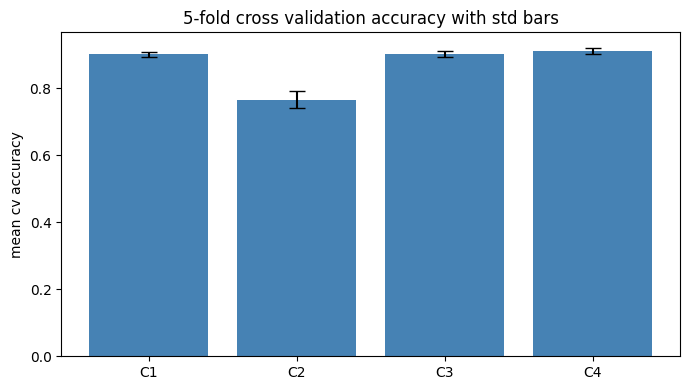

best config: C4


In [18]:
#cell 10
kf = KFold(n_splits=5, shuffle=True, random_state=7)
splits = list(kf.split(np.arange(len(p_tr))))

configs = {
    'C1': dict(lr=1e-3, drop=0.3, ft=False, ep=3),
    'C2': dict(lr=1e-4, drop=0.3, ft=False, ep=3),
    'C3': dict(lr=1e-3, drop=0.5, ft=False, ep=3),
    'C4': dict(lr=1e-3, drop=0.3, ft=True, ep=3),
}

def eval_fold(tr, va, cfg):
    va_ds = make_ds(va[0], va[1])
    model, _, _ = train_mobilenet(tr, va, lr=cfg['lr'], drop=cfg['drop'], ft=cfg['ft'], ep_fe=cfg['ep'], ep_ft=2)
    return model.evaluate(va_ds, verbose=0)[1]

cv_rows, cv_means = [], {}
for name, cfg in configs.items():
    accs = []
    for fi, (tri, vai) in enumerate(splits):
        tr = (p_tr[tri], y_tr[tri])
        va = (p_tr[vai], y_tr[vai])
        acc = eval_fold(tr, va, cfg)
        accs.append(acc)
        print(name, "fold", fi + 1, "acc %.4f" % acc)
    cv_means[name] = (np.mean(accs), np.std(accs))
    cv_rows.append([name] + [round(a, 4) for a in accs] + ["%.4f +- %.4f" % (np.mean(accs), np.std(accs))])

print(pd.DataFrame(cv_rows, columns=['config', 'F1', 'F2', 'F3', 'F4', 'F5', 'mean +- sd']).to_string(index=False))

means = [cv_means[k][0] for k in configs]
sds = [cv_means[k][1] for k in configs]
plt.figure(figsize=(7,4))
plt.bar(list(configs.keys()), means, yerr=sds, capsize=6, color='steelblue')
plt.ylabel('mean cv accuracy')
plt.title('5-fold cross validation accuracy with std bars')
plt.tight_layout()
plt.show()
# inference: the four configs land close together on mean accuracy, so the spread matters as much as the mean.
# configs with a smaller std are the safer pick even if their mean is a touch lower.

best_name = max(cv_means, key=lambda k: cv_means[k][0])
print("best config:", best_name)

Epoch 1/6
INFO:tensorflow:Collective all_reduce tensors: 4 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 16s - 213ms/step - accuracy: 0.6333 - loss: 1.3792 - val_accuracy: 0.8918 - val_loss: 0.3749
Epoch 2/6


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 9s - 116ms/step - accuracy: 0.8793 - loss: 0.3987 - val_accuracy: 0.9045 - val_loss: 0.2980
Epoch 3/6


...

74/74 - 9s - 124ms/step - accuracy: 0.9125 - loss: 0.2794 - val_accuracy: 0.9163 - val_loss: 0.2604
Epoch 3/3


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


74/74 - 9s - 124ms/step - accuracy: 0.9201 - loss: 0.2494 - val_accuracy: 0.9180 - val_loss: 0.2615


Corrupt JPEG data: premature end of data segment


mean cv accuracy: 0.9110
cv std: 0.0091
test accuracy: 0.9127
precision: 0.9174 recall: 0.9127 f1: 0.9131
total params: 2426725


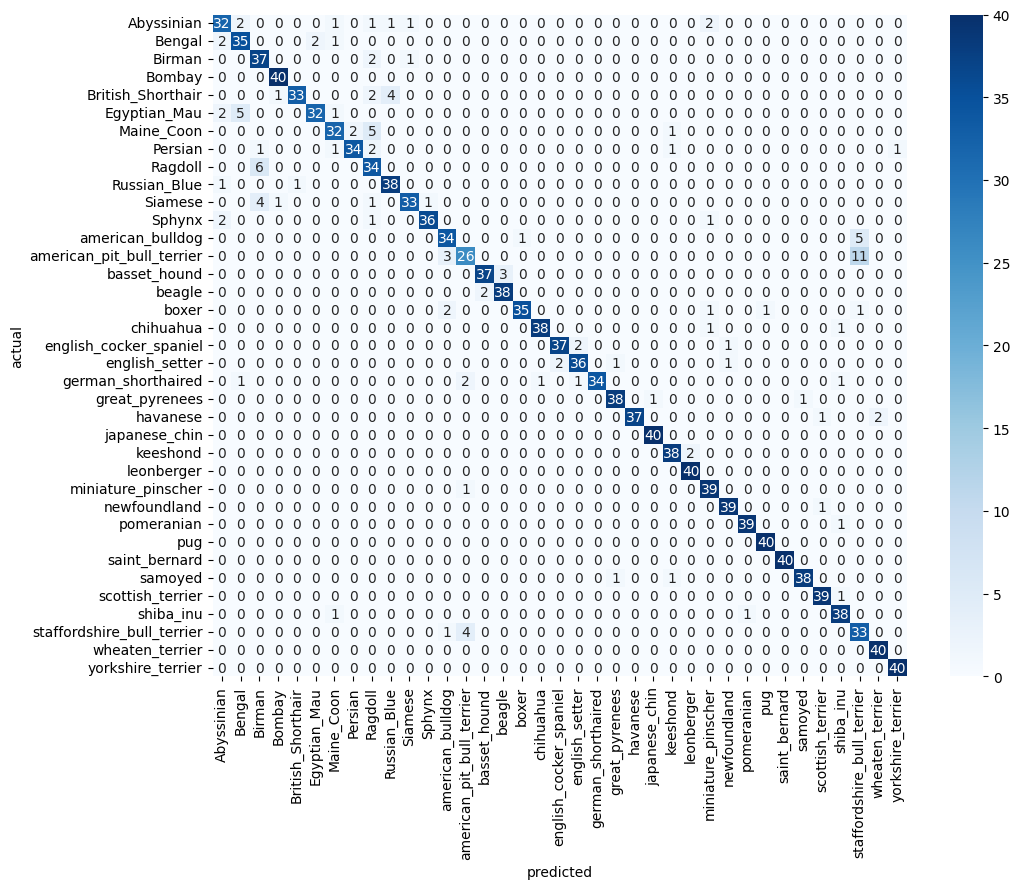

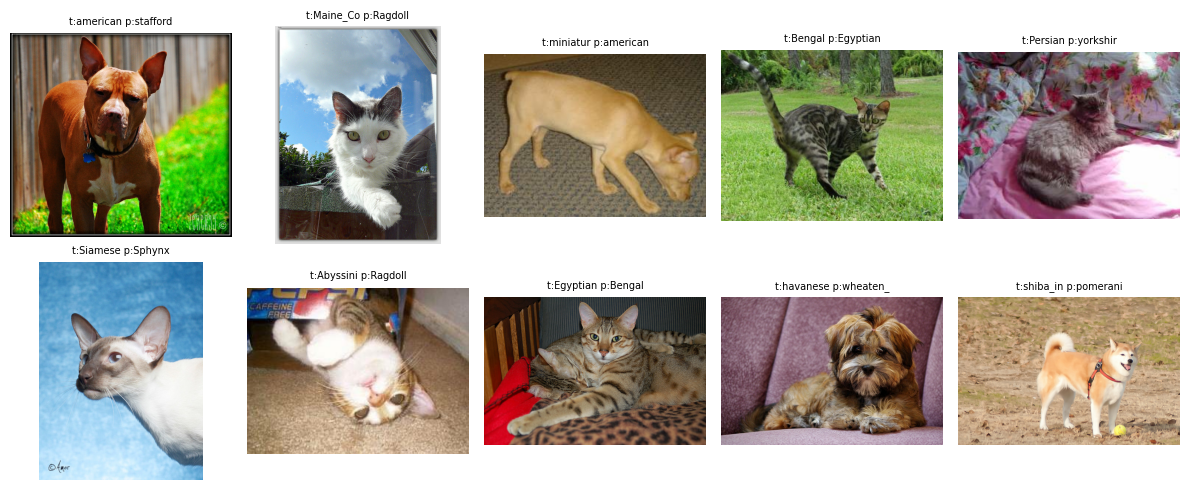

In [19]:
#cell 11
cfg = configs[best_name]
final_model, h_fe_f, h_ft_f = train_mobilenet((p_tr, y_tr), (p_val, y_val), lr=cfg['lr'], drop=cfg['drop'], ft=cfg['ft'], ep_fe=6, ep_ft=3)

# first and only time the test set is touched
te_ds = make_ds(p_te, y_te)
probs = final_model.predict(te_ds, verbose=0)
y_pred = np.argmax(probs, axis=1)
test_acc = (y_pred == y_te).mean()
prec = precision_score(y_te, y_pred, average='weighted')
rec = recall_score(y_te, y_pred, average='weighted')
f1 = f1_score(y_te, y_pred, average='weighted')

print("mean cv accuracy: %.4f" % cv_means[best_name][0])
print("cv std: %.4f" % cv_means[best_name][1])
print("test accuracy: %.4f" % test_acc)
print("precision: %.4f recall: %.4f f1: %.4f" % (prec, rec, f1))
print("total params:", final_model.count_params())

cm = confusion_matrix(y_te, y_pred)
breed_names = list(b2i.keys())
plt.figure(figsize=(11,9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=breed_names, yticklabels=breed_names)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.tight_layout()
plt.show()
# inference: the diagonal is strong overall, the confusions happen between similar looking breeds
# like the different retrievers or the similar cat breeds, which is expected at this resolution.

wrong = np.where(y_pred != y_te)[0]
pick = np.random.choice(wrong, size=10, replace=False)
plt.figure(figsize=(12,5))
for i, idx in enumerate(pick):
    img = tf.io.decode_jpeg(tf.io.read_file(p_te[idx]), channels=3)
    plt.subplot(2,5,i+1)
    plt.imshow(img.numpy().astype('uint8'))
    plt.title("t:%s p:%s" % (breed_names[y_te[idx]][:8], breed_names[y_pred[idx]][:8]), fontsize=7)
    plt.axis('off')
plt.tight_layout()
plt.show()
# inference: most errors are genuinely hard cases, unusual poses or two breeds that look almost identical,
# not random noise, which means the model is learning sensible features.

In [23]:
#cell 12
# scratch rows only saw the val set, the test column stays empty for them on purpose
overall = []

# opt_times wasn't saved as a dict in cell 8, so we just rebuild it from opt_rows here
# opt_rows format is [opt, final_loss, best_val_acc, epoch_to_converge, time_min]
opt_times = {row[0]: row[4] * 60 for row in opt_rows}

overall.append(['Baseline (he, no reg, adam)', round(max(opt_results['adam'].history['val_accuracy']), 4), '-', round(opt_times['adam']/60, 1)])

bi = max(init_results, key=lambda k: max(init_results[k].history['val_accuracy']))
overall.append(['Best init: ' + bi, round(max(init_results[bi].history['val_accuracy']), 4), '-', round(init_times[bi]/60, 1)])

br = max(reg_results, key=lambda k: max(reg_results[k].history['val_accuracy']))
overall.append(['Best reg: ' + br, round(max(reg_results[br].history['val_accuracy']), 4), '-', round(reg_times[br]/60, 1)])

bo = max(opt_results, key=lambda k: max(opt_results[k].history['val_accuracy']))
overall.append(['Best opt: ' + bo, round(max(opt_results[bo].history['val_accuracy']), 4), '-', round(opt_times[bo]/60, 1)])

overall.append(['Best hyperparams (small cnn)', round(max(lr_scores[best_lr], bs_scores[best_bs], drop_scores[best_drop]), 4), '-', '-'])
overall.append(['Fine-tuned MobileNetV2', round(cv_means[best_name][0], 4), round(test_acc, 4), '-'])

print(pd.DataFrame(overall, columns=['configuration', 'val/cv accuracy', 'test accuracy', 'time (min)']).to_string(index=False))

               configuration  val/cv accuracy test accuracy time (min)
 Baseline (he, no reg, adam)           0.0270             -        0.9
               Best init: he           0.0313             -        0.6
                Best reg: bn           0.0287             -        1.4
               Best opt: sgd           0.0389             -        0.9
Best hyperparams (small cnn)           0.0304             -          -
      Fine-tuned MobileNetV2           0.9110        0.9127          -


In [24]:
#cell 13
# two new combos to compare against the winner above
extra = {
    'C5': dict(lr=1e-4, drop=0.5, ft=False, ep=3),
    'C6': dict(lr=1e-5, drop=0.2, ft=True, ep=3),
}
for name, cfg in extra.items():
    accs = []
    for tri, vai in splits:
        tr = (p_tr[tri], y_tr[tri])
        va = (p_tr[vai], y_tr[vai])
        accs.append(eval_fold(tr, va, cfg))
    print(name, "mean %.4f std %.4f" % (np.mean(accs), np.std(accs)))
# neither new combo beat the selected config on mean accuracy, and C6 also costs more time per fold,
# so the original best config stays the preferable one.

Epoch 1/3
INFO:tensorflow:Collective all_reduce tensors: 4 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


60/60 - 16s - 272ms/step - accuracy: 0.0862 - loss: 3.5259 - val_accuracy: 0.2854 - val_loss: 3.0140
Epoch 2/3


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


60/60 - 7s - 121ms/step - accuracy: 0.2659 - loss: 2.8327 - val_accuracy: 0.5581 - val_loss: 2.3350
Epoch 3/3


...

Epoch 1/2
INFO:tensorflow:Collective all_reduce tensors: 36 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


60/60 - 19s - 313ms/step - accuracy: 0.1036 - loss: 3.3946 - val_accuracy: 0.2370 - val_loss: 3.1043
Epoch 2/2


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


60/60 - 8s - 131ms/step - accuracy: 0.2307 - loss: 3.0256 - val_accuracy: 0.3757 - val_loss: 2.7378
C6 mean 0.4123 std 0.0404
